In [1]:
import os
import pandas as pd
import pyodbc
import numpy as np

# Set these in your environment for local execution:
#   setx NORTHWIND_SQL_SERVER "localhost\\SQLEXPRESS"
#   setx NORTHWIND_SQL_DATABASE "Northwind"
# (then restart Jupyter kernel)
server = os.getenv("NORTHWIND_SQL_SERVER", "YOUR_SERVER")
database = os.getenv("NORTHWIND_SQL_DATABASE", "YOUR_DATABASE")

print(f"Using SQL Server: {server}")
print(f"Using Database: {database}")

C:\Users\ybobr\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import pandas as pd
import pyodbc

# 1. Build connection
if server in {"YOUR_SERVER", ""} or database in {"YOUR_DATABASE", ""}:
    raise ValueError(
        "SQL connection is masked for safety. Set NORTHWIND_SQL_SERVER and NORTHWIND_SQL_DATABASE "
        "environment variables (or replace placeholders locally) before running."
    )

conn = pyodbc.connect(
    "Driver={SQL Server};"
    f"Server={server};"
    f"Database={database};"
    "Trusted_Connection=yes;"
)

try:

    df_sales = pd.read_sql("SELECT * FROM vw_MasterSales", conn)
    df_logistics = pd.read_sql("SELECT * FROM vw_LogisticsAndShipping", conn)
    df_inventory = pd.read_sql("SELECT * FROM vw_InventoryPerformance", conn)
    df_customer = pd.read_sql("SELECT * FROM vw_CustomerAnalytics", conn)


    df_merged = pd.merge(
        df_sales, 
        df_logistics.drop(columns=['CustomerID']), 
        on='OrderID', 
        how='left')

    df_merged = pd.merge(
        df_merged, 
        df_inventory.drop(columns=['ProductName', 'CategoryName']), 
        on='ProductID', 
        how='left')

 
    df_final = pd.merge(
        df_merged, 
        df_customer, 
        on='CustomerID', 
        how='left')



finally:

    conn.close()

C:\Users\ybobr\AppData\Local\Temp\ipykernel_23012\4105441671.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales = pd.read_sql("SELECT * FROM vw_MasterSales", conn)
C:\Users\ybobr\AppData\Local\Temp\ipykernel_23012\4105441671.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_logistics = pd.read_sql("SELECT * FROM vw_LogisticsAndShipping", conn)
C:\Users\ybobr\AppData\Local\Temp\ipykernel_23012\4105441671.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_inventory = pd.read_sql("SELECT * FROM vw_Invento

In [3]:
df_final

,OrderID,CustomerID,OrderDate,ProductID,ProductName,CategoryName,UnitCost,UnitPrice,Quantity,Discount,...,DeliveryDuration,IsLate,UnitsInStock,ReorderLevel,Discontinued,SupplierName,StockValue,CompanyName,Country,City
0,10248,VINET,1996-07-04,11,Queso Cabrales,Dairy Products,13.65,14.00,12,0.00,...,12.0,0,22,30,False,Cooperativa de Quesos 'Las Cabras',300.30,Vins et alcools Chevalier,France,Reims
1,10248,VINET,1996-07-04,42,Singaporean Hokkien Fried Mee,Grains/Cereals,9.80,9.80,10,0.00,...,12.0,0,26,0,True,Leka Trading,254.80,Vins et alcools Chevalier,France,Reims
2,10248,VINET,1996-07-04,72,Mozzarella di Giovanni,Dairy Products,22.62,34.80,5,0.00,...,12.0,0,14,0,False,Formaggi Fortini s.r.l.,316.68,Vins et alcools Chevalier,France,Reims
3,10249,TOMSP,1996-07-05,14,Tofu,Produce,13.95,18.60,9,0.00,...,5.0,0,35,0,False,Mayumi's,488.25,Toms Spezialitäten,Germany,Münster
4,10249,TOMSP,1996-07-05,51,Manjimup Dried Apples,Produce,31.80,42.40,40,0.00,...,5.0,0,20,10,False,"G'day, Mate",636.00,Toms Spezialitäten,Germany,Münster
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,11077,RATTC,1998-05-06,64,Wimmers gute Semmelknödel,Grains/Cereals,23.28,33.25,2,0.03,...,NaN,0,22,30,False,Plutzer Lebensmittelgroßmärkte AG,512.16,Rattlesnake Canyon Grocery,USA,Albuquerque
2151,11077,RATTC,1998-05-06,66,Louisiana Hot Spiced Okra,Condiments,10.20,17.00,1,0.00,...,NaN,0,4,20,False,New Orleans Cajun Delights,40.80,Rattlesnake Canyon Grocery,USA,Albuquerque
2152,11077,RATTC,1998-05-06,73,Röd Kaviar,Seafood,10.50,15.00,2,0.01,...,NaN,0,101,5,False,Svensk Sjöföda AB,1060.50,Rattlesnake Canyon Grocery,USA,Albuquerque
2153,11077,RATTC,1998-05-06,75,Rhönbräu Klosterbier,Beverages,4.26,7.75,4,0.00,...,NaN,0,125,25,False,Plutzer Lebensmittelgroßmärkte AG,532.50,Rattlesnake Canyon Grocery,USA,Albuquerque


In [4]:
df_final["CategoryName"].unique()

<ArrowStringArray>
['Dairy Products', 'Grains/Cereals',        'Produce',        'Seafood',
     'Condiments',    'Confections',      'Beverages',   'Meat/Poultry']
Length: 8, dtype: str

In [5]:
df_final.isnull().sum()

OrderID              0
CustomerID           0
OrderDate            0
ProductID            0
ProductName          0
CategoryName         0
UnitCost             0
UnitPrice            0
Quantity             0
Discount             0
GrossSales           0
NetSales             0
Profit               0
ShippedDate         73
RequiredDate         0
Freight              0
ShipCountry          0
ShipperName          0
EmployeeName         0
DeliveryDuration    73
IsLate               0
UnitsInStock         0
ReorderLevel         0
Discontinued         0
SupplierName         0
StockValue           0
CompanyName          0
Country              0
City                 0
dtype: int64

In [6]:
df_final.describe()

,OrderID,OrderDate,ProductID,UnitCost,UnitPrice,Quantity,Discount,GrossSales,NetSales,Profit,ShippedDate,RequiredDate,Freight,DeliveryDuration,IsLate,UnitsInStock,ReorderLevel,StockValue
count,2155.000000,2155,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2082,2155,2155.000000,2082.000000,2155.000000,2155.000000,2155.000000,2155.000000
mean,10659.375870,1997-08-05 06:12:11.693735,40.793039,17.414770,26.218520,23.812993,0.056167,628.519067,587.374960,168.441889,1997-08-04 04:05:31.988472,1997-09-02 02:27:40.510440,96.197726,8.345341,0.042691,39.795824,11.900232,569.638051
min,10248.000000,1996-07-04 00:00:00,1.000000,1.630000,2.000000,1.000000,0.000000,4.800000,4.800000,-292.500000,1996-07-10 00:00:00,1996-07-24 00:00:00,0.020000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,10451.000000,1997-02-19 00:00:00,22.000000,7.800000,12.000000,10.000000,0.000000,154.000000,147.000000,30.150000,1997-02-24 00:00:00,1997-03-18 12:00:00,19.610000,4.000000,0.000000,17.000000,0.000000,171.000000
50%,10657.000000,1997-09-04 00:00:00,41.000000,12.810000,18.400000,20.000000,0.000000,360.000000,337.750000,83.799988,1997-09-01 00:00:00,1997-10-02 00:00:00,53.800000,7.000000,0.000000,25.000000,10.000000,384.300000
75%,10862.500000,1998-01-31 12:00:00,60.000000,22.620000,32.000000,30.000000,0.100000,722.250000,656.000000,186.985001,1998-01-30 00:00:00,1998-03-03 00:00:00,120.920000,9.000000,0.000000,57.000000,20.000000,636.000000
max,11077.000000,1998-05-06 00:00:00,77.000000,144.930000,263.500000,130.000000,0.250000,15810.000000,15810.000000,7114.200195,1998-05-06 00:00:00,1998-06-11 00:00:00,1007.640000,37.000000,1.000000,125.000000,30.000000,2824.250000
std,241.378032,NaN,22.159019,19.124203,29.827418,19.022047,0.083450,1036.466980,969.224236,353.234386,NaN,NaN,133.011272,6.692846,0.202207,36.055668,10.791421,648.238361


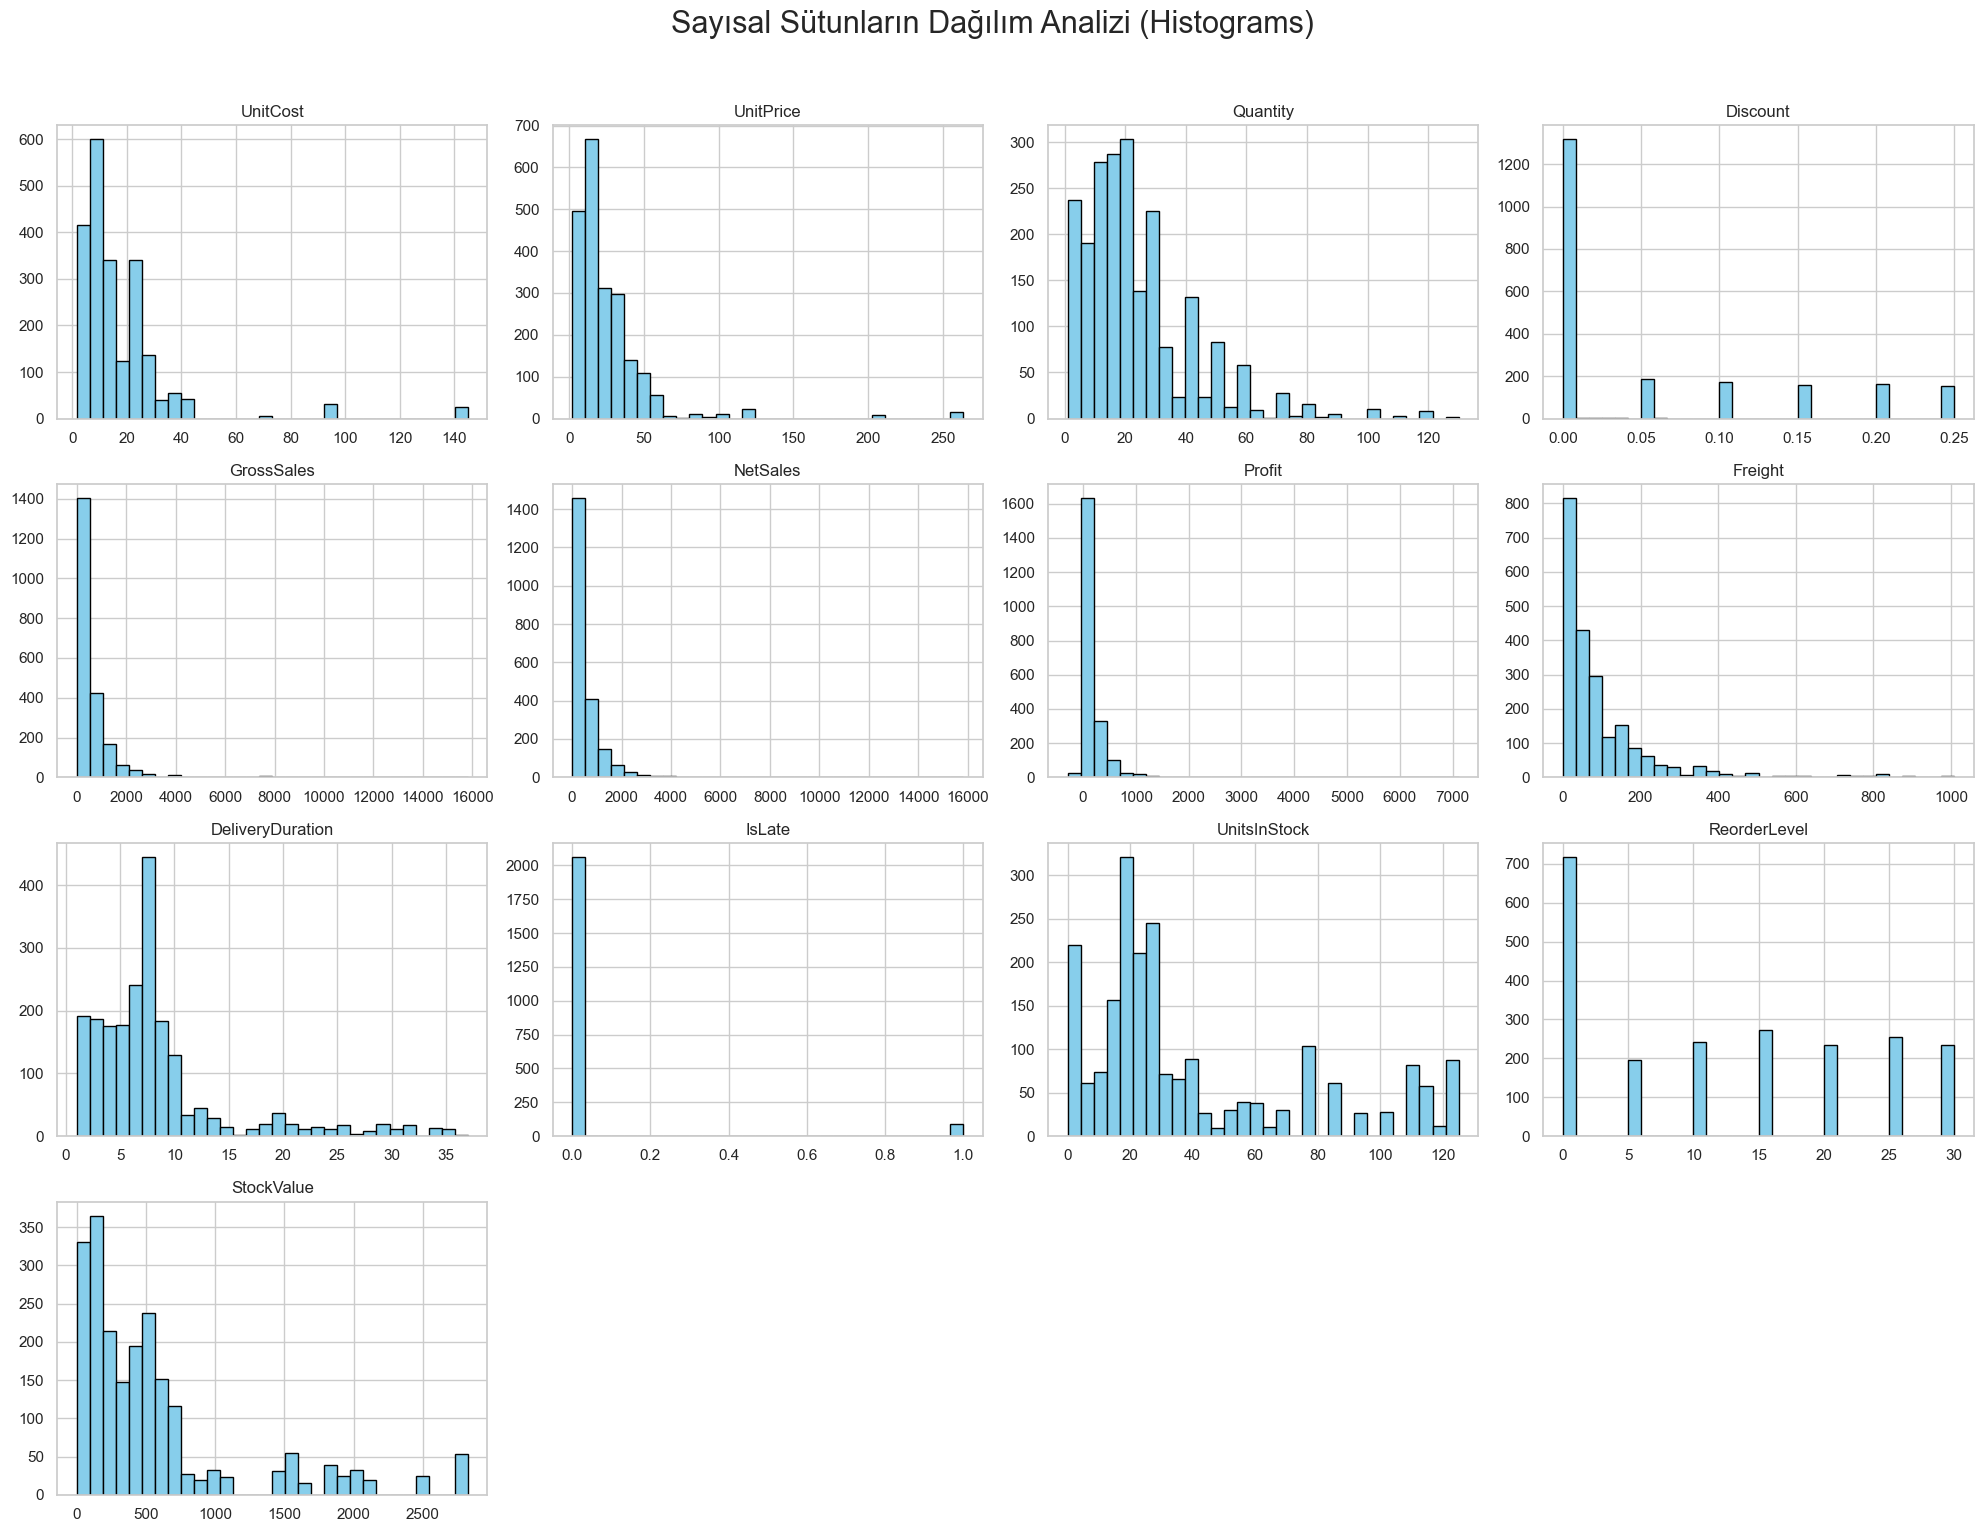

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Görselleştirme stilini ayarlayalım
sns.set_theme(style="whitegrid")

# 2. Sadece sayısal sütunları seçelim
# 'OrderID', 'ProductID' gibi ID sütunlarını görselleştirmemek için onları çıkarabiliriz
excluded_cols = ['OrderID', 'ProductID']
numerical_cols = [col for col in df_final.select_dtypes(include=['number']).columns if col not in excluded_cols]

# 3. Grafik matrisini oluşturalım
# Sütun sayısına göre satır/sütun düzenini otomatik ayarlar
df_final[numerical_cols].hist(bins=30, figsize=(20, 15), layout=(-1, 4), color='skyblue', edgecolor='black')

# 4. Başlık ve düzenlemeler
plt.suptitle('Sayısal Sütunların Dağılım Analizi (Histograms)', fontsize=22, y=1.02)
plt.tight_layout()

# 5. Grafiği kaydet ve göster
plt.savefig('sayisal_dagilimlar.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 2000x1000 with 0 Axes>

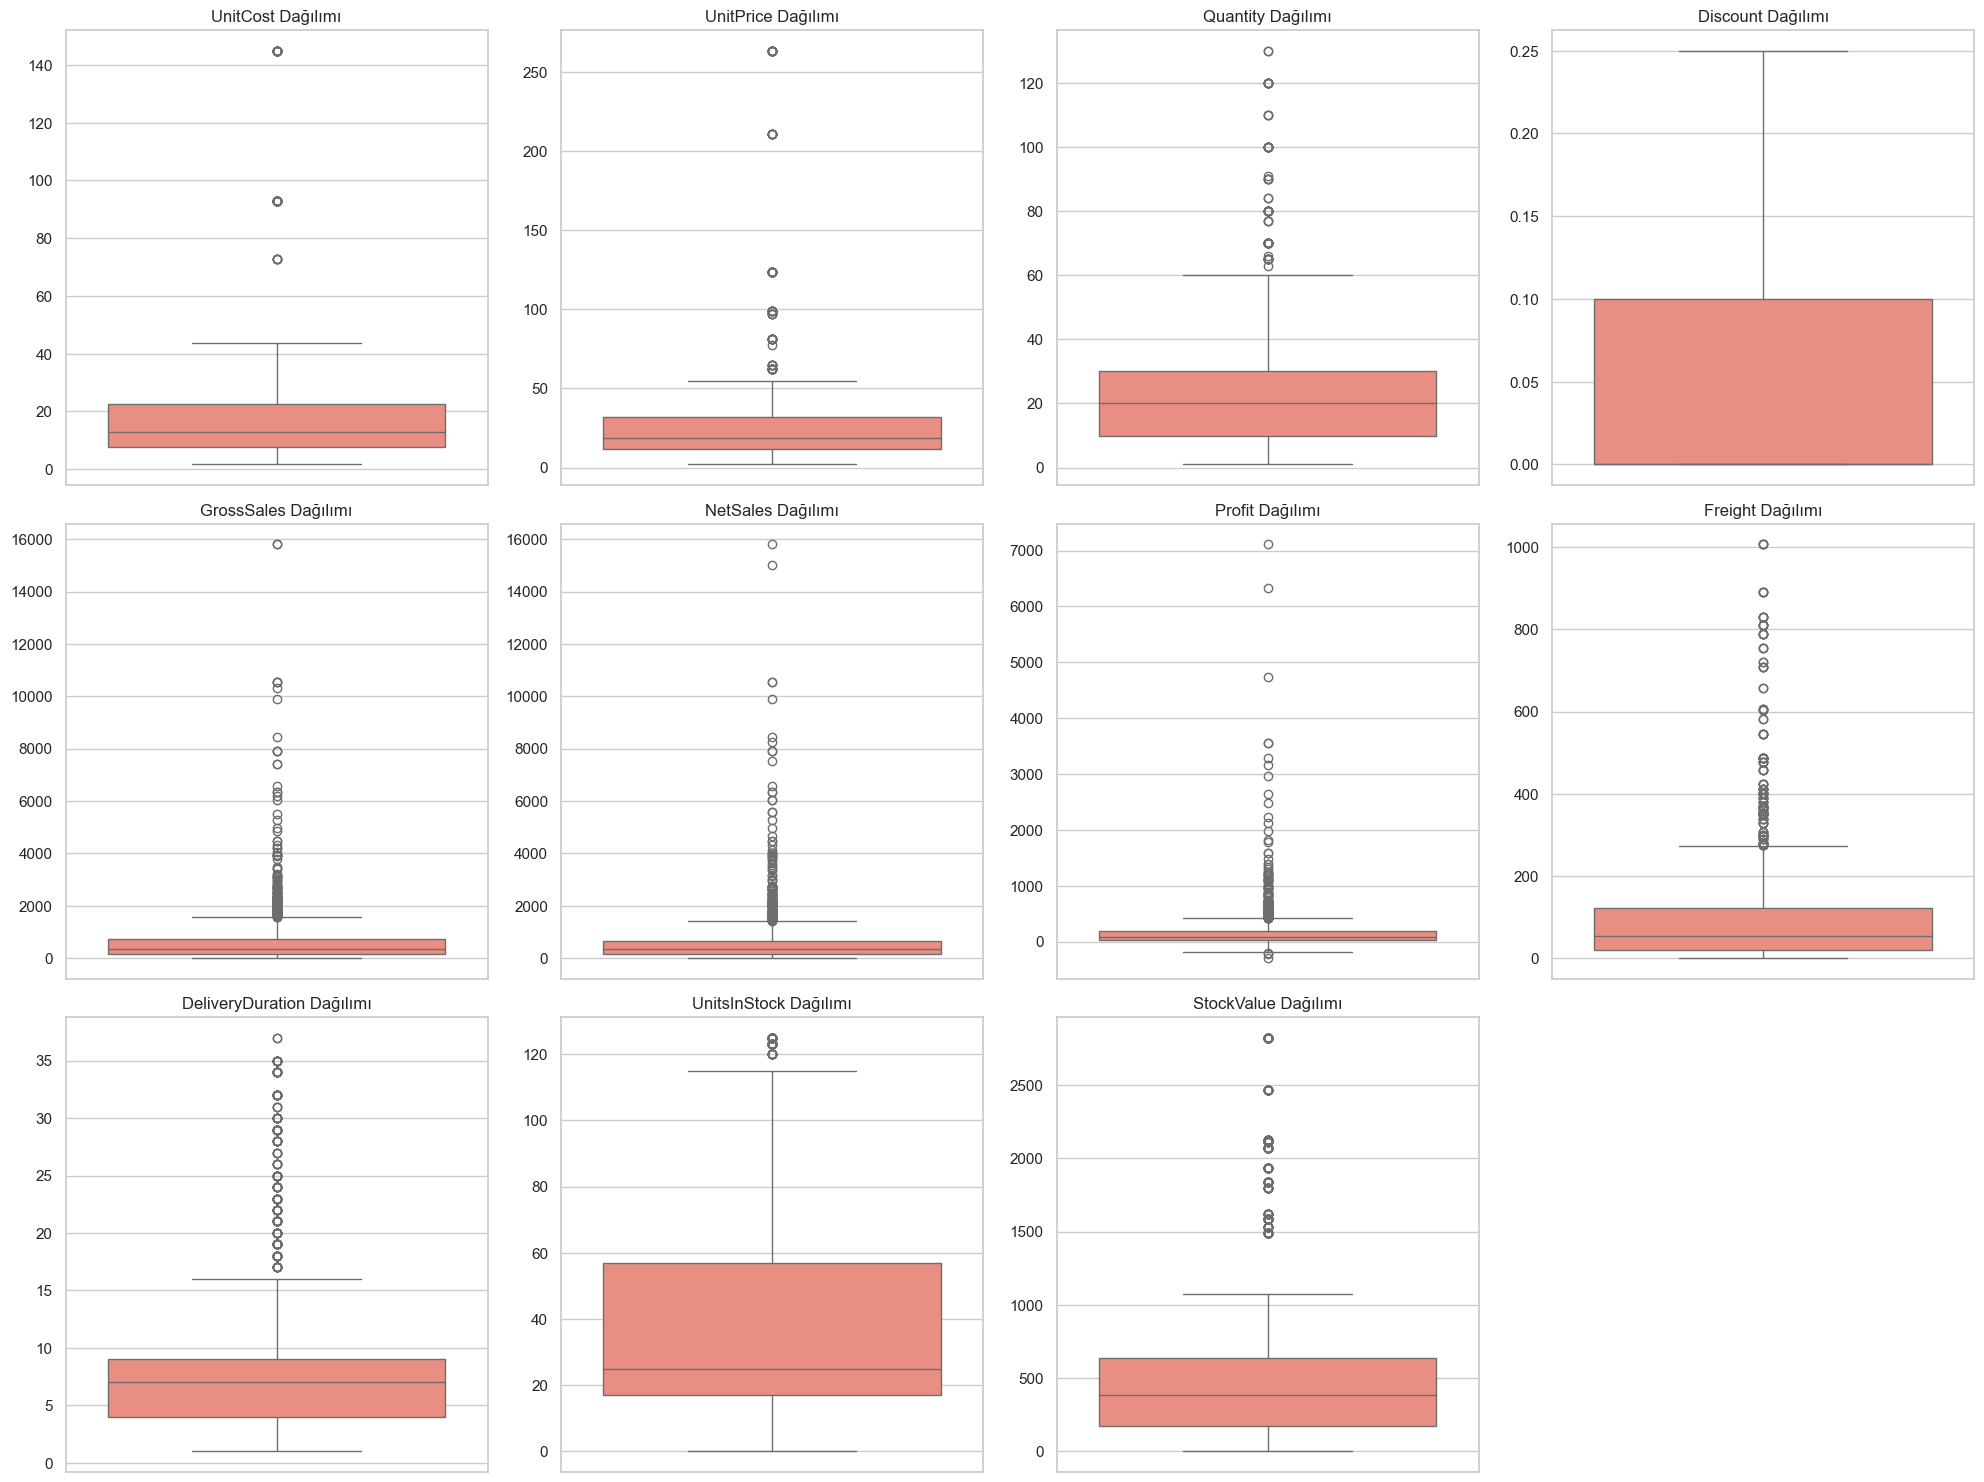

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Görselleştirme temasını ayarlayalım
sns.set_theme(style="whitegrid")

# 2. Analiz edilecek sayısal sütunları seçelim (ID'leri hariç tutuyoruz)
cols_to_plot = [
    'UnitCost', 'UnitPrice', 'Quantity', 'Discount', 
    'GrossSales', 'NetSales', 'Profit', 'Freight', 
    'DeliveryDuration', 'UnitsInStock', 'StockValue'
]

# 3. Grafik alanını oluşturalım (Sütun sayısına göre genişliği ayarlıyoruz)
plt.figure(figsize=(20, 10))

# 4. Veriyi 'melt' ederek tüm sütunları tek bir grafikte yan yana görelim
# Not: Sütunların ölçekleri çok farklı olduğu için (Örn: Discount 0.1 iken Profit 1000 olabilir)
# her birini ayrı subplot'larda görmek daha sağlıklıdır.
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df_final, y=col, ax=axes[i], color='salmon')
    axes[i].set_title(f'{col} Dağılımı', fontsize=12)
    axes[i].set_ylabel('')

# Kullanılmayan boş subplot'ları kapatalım
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('kutu_grafikleri.png', dpi=300)
plt.show()

In [12]:
kpi = {
    "Total Revenue": df_final["NetSales"].sum(),
    "Total Profit": df_final["Profit"].sum(),
    "Total Orders": df_final["OrderID"].nunique(),
    "Total Quantity": df_final["Quantity"].sum()
}

kpi

{'Total Revenue': np.float64(1265793.0396184921),
 'Total Profit': np.float64(362992.27029657364),
 'Total Orders': 830,
 'Total Quantity': np.int64(51317)}

<Axes: title={'center': 'Monthly Sales & Profit'}, xlabel='OrderDate'>

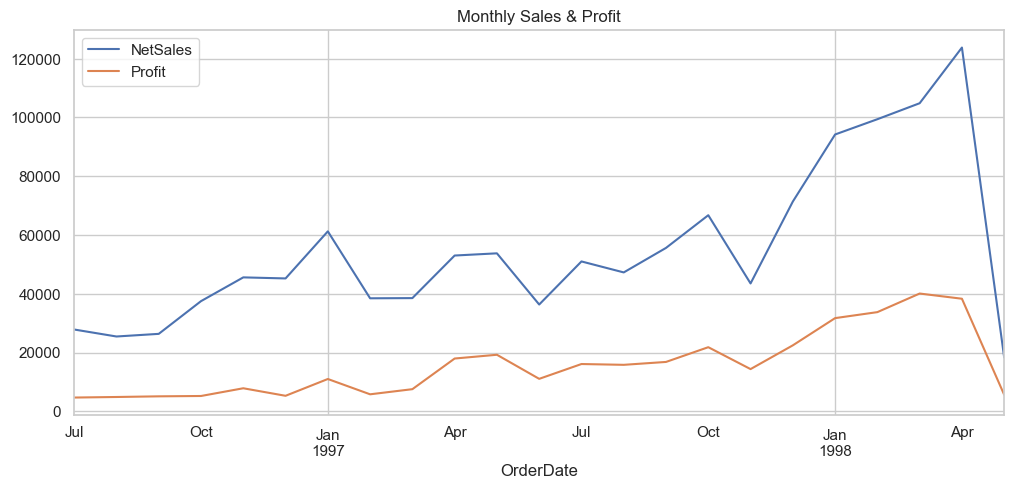

In [13]:
df_final["OrderDate"] = pd.to_datetime(df_final["OrderDate"])

monthly_sales = df_final.resample("ME", on="OrderDate")[["NetSales", "Profit"]].sum()

monthly_sales.plot(figsize=(12,5), title="Monthly Sales & Profit")

In [14]:
category_analysis = df_final.groupby("CategoryName").agg({
    "UnitCost" : "mean",
    "Discount" : "mean",
    'GrossSales': 'sum',
    'NetSales': 'sum',
    'Profit': 'sum' 
})

category_analysis['Profit_Margin (%)'] = (
    category_analysis['Profit'] / category_analysis['NetSales'].replace(0, np.nan)
) * 100

category_analysis['Profit_Share (%)'] = (
    category_analysis['Profit'] / category_analysis['Profit'].sum()
) * 100

category_analysis = category_analysis.rename(columns={'Profit': 'GrossProfit'})

category_analysis = category_analysis.sort_values("Profit_Share (%)", ascending=False).round(2)

print(category_analysis)

                UnitCost  Discount  GrossSales   NetSales  GrossProfit  \
CategoryName                                                             
Beverages          17.15      0.06   286526.95  267868.18     97592.09   
Confections        12.09      0.06   177099.10  167357.22     72181.53   
Dairy Products     18.78      0.05   251330.50  234507.29     59557.85   
Produce            22.43      0.05   105268.60   99984.58     33147.58   
Condiments         13.58      0.05   113694.75  106047.08     32641.28   
Seafood            14.08      0.06   141623.09  131261.74     26914.33   
Grains/Cereals     15.87      0.05   100726.80   95744.59     20947.29   
Meat/Poultry       34.39      0.06   178188.80  163022.36     20010.32   

                Profit_Margin (%)  Profit_Share (%)  
CategoryName                                         
Beverages                   36.43             26.89  
Confections                 43.13             19.89  
Dairy Products              25.40          

Executive Summary of Category Performance

-Primary Profit Drivers: Beverages remains the most significant contributor to the bottom line, accounting for 26.89% of the total profit share with a strong 36.43% profit margin.

-Operational Efficiency: Confections stands out as the most efficient category, boasting the highest profit margin at 43.13%. This indicates high value-added sales despite lower unit costs compared to other categories.

-Performance Concerns: Meat/Poultry exhibits the lowest profitability. Despite having the highest average unit cost (34.39), its profit margin is only 12.27%, suggesting high procurement costs or intense price competition that erodes margins.

-Strategic Concentration: The top three categories (Beverages, Confections, and Dairy Products) collectively generate over 63% of the total gross profit, highlighting their critical importance to the company's financial stability.

In [15]:
total_company_profit = df_final['Profit'].sum()

product_analysis = df_final.groupby("ProductName").agg({
    'NetSales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'UnitCost': 'mean',   # Ortalama birim maliyet
    'Discount': 'mean'    # Ortalama indirim oranı
})

top_products = product_analysis.sort_values("NetSales", ascending=False).head(10).copy()
top_products['Profit_Margin (%)'] = (top_products['Profit'] / top_products['NetSales']) * 100
top_products['Profit_Share (%)'] = (top_products['Profit'] / total_company_profit) * 100

print(top_products.sort_values("Profit_Share (%)", ascending=False).round(2))

                          NetSales    Profit  Quantity  UnitCost  Discount  \
ProductName                                                                  
Côte de Blaye            141396.74  51105.35       623    144.93      0.05   
Tarte au sucre            47234.97  20539.02      1083     24.65      0.05   
Raclette Courdavault      71155.70  17673.70      1496     35.75      0.05   
Manjimup Dried Apples     41819.65  13644.85       886     31.80      0.05   
Camembert Pierrot         46825.48  11973.78      1577     22.10      0.06   
Thüringer Rostbratwurst   80368.67  11110.03       746     92.84      0.06   
Gnocchi di nonna Alice    42593.06   8997.26      1263     26.60      0.06   
Rössle Sauerkraut         25696.64   8186.24       640     27.36      0.04   
Carnarvon Tigers          29171.88   5590.62       539     43.75      0.08   
Alice Mutton              32698.38   4091.88       978     29.25      0.06   

                         Profit_Margin (%)  Profit_Share (%)  


English Analysis: Top 10 Products Performance

-The Undisputed Leader: Côte de Blaye is the most critical asset for the business. It alone accounts for 14.08% of the company’s total profit with a solid 36.14% margin. It is a high-ticket, high-profit item.

-Efficiency Champion: Tarte au sucre boasts the highest efficiency among top-tier products with a 43.48% profit margin. Despite having lower sales volume than others, its profitability makes it a high-value focus.

-Volume vs. Margin Trade-off: Thüringer Rostbratwurst and Alice Mutton represent a challenge. While they generate significant revenue, their margins are low (13.82% and 12.51% respectively). This suggests high production/acquisition costs or a highly competitive pricing strategy.

-Revenue Concentration: The top 3 products (Côte de Blaye, Thüringer Rostbratwurst, and Raclette Courdavault) generate a massive portion of the net sales, but their profit contributions vary wildly.

In [16]:
product_analysis = df_final.groupby("ProductName").agg({
    'NetSales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'UnitCost': 'mean',
    'UnitPrice': 'mean', # Satış fiyatını da görelim ki kıyaslayalım
    'Discount': 'mean'
})
loss_making_products = product_analysis[product_analysis['Profit'] < 0].sort_values("Profit")
loss_making_products['Loss_Margin (%)'] = (loss_making_products['Profit'] / loss_making_products['NetSales']) * 100
loss_making_products['Cost_vs_Price_Diff'] = loss_making_products['UnitPrice'] - loss_making_products['UnitCost']

print(loss_making_products.round(2))
#No loss-making category has been identified.

Empty DataFrame
Columns: [NetSales, Profit, Quantity, UnitCost, UnitPrice, Discount, Loss_Margin (%), Cost_vs_Price_Diff]
Index: []


In [17]:
df_final[df_final["Profit"]<= 0][["ProductName","Profit"]].value_counts(ascending=True)


ProductName                      Profit     
Singaporean Hokkien Fried Mee     0.000000      1
Pâté chinois                     -35.279968     1
Jack's New England Clam Chowder  -15.760010     1
Nord-Ost Matjeshering            -155.699951    1
Longlife Tofu                     0.000000      1
                                               ..
Tourtière                        -0.050003      1
Mascarpone Fabioli               -1.919998      2
Gnocchi di nonna Alice           -68.399963     2
Pâté chinois                     -86.400146     2
Alice Mutton                      0.000000      3
Name: count, Length: 75, dtype: int64

In [18]:
losses_df=df_final[df_final["Profit"] <= 0].copy()
top_losses = losses_df[['ProductName', 'UnitPrice', 'UnitCost', 'Discount', 'Quantity', 'Profit']].sort_values("Profit").head(10)
top_losses

,ProductName,UnitPrice,UnitCost,Discount,Quantity,Profit
485,Alice Mutton,31.2,29.25,0.25,50,-292.500000
568,Pâté chinois,19.2,18.00,0.25,60,-216.000000
510,Thüringer Rostbratwurst,99.0,92.84,0.15,24,-208.559814
481,Alice Mutton,31.2,29.25,0.20,45,-193.049927
45,Nord-Ost Matjeshering,20.7,18.12,0.25,60,-155.699951
223,Carnarvon Tigers,50.0,43.75,0.20,40,-150.000000
101,Perth Pasties,26.2,24.60,0.20,36,-131.039978
332,Camembert Pierrot,27.2,22.10,0.25,70,-119.000000
254,Pâté chinois,19.2,18.00,0.20,40,-105.599976
154,Thüringer Rostbratwurst,99.0,92.84,0.10,25,-93.500000


Root Cause Analysis of Transactional Losses

-The "Discount Trap": The data clearly indicates that the losses are not due to high costs alone, but due to aggressive discounting on low-margin products. > * Negative Unit Margin: For products like Alice Mutton and Pâté chinois, the gross margin is too thin (approx. 6-7%) to support standard discounts of 15% or 20%. Any discount above 7% on these items results in a "selling-at-a-loss" scenario.

-Scale of Impact: High-volume orders (e.g., 60-70 units) amplify these pricing errors, leading to significant single-transaction losses that erode the profits generated by other successful sales.

-Recommendation: Implement a product-specific "Discount Ceiling" (Maximum allowable discount) based on the specific gross margin of each item.

In [19]:
shipped_df = df_final[df_final['DeliveryDuration'].notna()].copy()
order_level = shipped_df.groupby(['OrderID', 'ShipperName']).agg({
    'DeliveryDuration': 'median',  # Her siparişin teslim süresi
    'Freight': 'first',            # Sipariş başına kargo ücreti
    'IsLate': 'max'                # Sipariş gecikme durumu
}).reset_index()

logistics_pro = order_level.groupby("ShipperName").agg({
    'OrderID': 'nunique',          
    'DeliveryDuration': 'median',   
    'Freight': 'median',            
    'IsLate': 'mean'                
})

logistics_pro.columns = ['Total_Shipments', 'Median_Delivery_Days', 'Median_Freight', 'Late_Rate_Ratio']

logistics_pro['Late_Rate (%)'] = (logistics_pro['Late_Rate_Ratio'] * 100).round(2)

final_report = logistics_pro.sort_values(["Median_Delivery_Days", "Late_Rate (%)"])
final_report=final_report.drop("Late_Rate_Ratio",axis=1)
final_report

,Total_Shipments,Median_Delivery_Days,Median_Freight,Late_Rate (%)
ShipperName,,,,
Federal Shipping,249,6.0,38.11,3.61
Speedy Express,245,7.0,41.34,4.90
United Package,315,7.0,44.17,5.08


Explanation:

Total_Shipments:
The total number of orders shipped by each logistics provider. For example, United Package handled the highest number of shipments (315).
Median_Delivery_Days:
The median number of days taken to deliver an order.
Federal Shipping is the fastest with a median delivery time of 6 days.
Both Speedy Express and United Package have a median of 7 days.
Median_Freight:
The median shipping cost per order.
Federal Shipping is the most cost-effective with a median freight of 38.11.
United Package is the most expensive (44.17).
Late_Rate (%):
The percentage of orders delivered late.
Federal Shipping has the lowest late rate (3.61%), indicating higher reliability.
United Package has the highest late rate (5.08%).

In [20]:

shipped_df = df_final[df_final['DeliveryDuration'].notna()].copy()

# Sadece geciken siparişler
late_orders = shipped_df[shipped_df['IsLate'] == 1].copy()

order_level = late_orders.groupby(['OrderID', 'ShipperName', 'ShipCountry']).agg({
    'DeliveryDuration': 'median',  # Her siparişin teslim süresi
    'Freight': 'first'             # Sipariş başına kargo ücreti
}).reset_index()

logistics_late = order_level.groupby(['ShipperName', 'ShipCountry']).agg({
    'OrderID': 'nunique',           # Toplam geciken sipariş sayısı
    'DeliveryDuration': 'median',   # Median teslim süresi
    'Freight': 'median'             # Median kargo ücreti
})

logistics_late.columns = ['Late_Shipments', 'Median_Delivery_Days', 'Median_Freight']


final_late_report = logistics_late.sort_values(['Late_Shipments', 'Median_Delivery_Days'], ascending=[False, True])

final_late_report

Late_Shipments  Median_Delivery_Days  \
ShipperName      ShipCountry                                         
United Package   USA                       4                  30.5   
                 France                    2                  24.0   
                 UK                        2                  29.0   
Speedy Express   Italy                     2                  31.0   
United Package   Germany                   2                  32.0   
Federal Shipping Brazil                    2                  33.0   
Speedy Express   USA                       2                  34.5   
Federal Shipping Finland                   1                  15.0   
                 USA                       1                  19.0   
Speedy Express   Venezuela                 1                  20.0   
Federal Shipping Germany                   1                  21.0   
Speedy Express   Argentina                 1                  22.0   
Federal Shipping Portugal                  1                  29.0   
Speedy Express   Sweden                    1                  29.0   
United Package   Belgium                   1                  29.0   
Federal Shipping Sweden                    1                  30.0   
Speedy Express   Germany                   1                  30.0   
United Package   Ireland                   1                  30.0   
Federal Shipping UK                        1                  31.0   
Speedy Express   Spain                     1                  31.0   
                 UK                        1                  32.0   
                 France                    1                  34.0   
                 Ireland                   1                  34.0   
United Package   Venezuela                 1                  34.0   
Federal Shipping Ireland                   1                  35.0   
United Package   Austria                   1                  35.0   
                 Sweden                    1                  35.0   
                 Brazil                    1                  37.0   

                              Median_Freight  
ShipperName      ShipCountry                  
United Package   USA                  13.600  
                 France               88.345  
                 UK                   69.580  
Speedy Express   Italy                45.630  
United Package   Germany             116.165  
Federal Shipping Brazil              117.650  
Speedy Express   USA                  63.815  
Federal Shipping Finland              34.570  
                 USA                 487.570  
Speedy Express   Venezuela             2.080  
Federal Shipping Germany             189.090  
Speedy Express   Argentina            90.850  
Federal Shipping Portugal             73.830  
Speedy Express   Sweden                8.980  
United Package   Belgium               6.270  
Federal Shipping Sweden                3.670  
Speedy Express   Germany             204.470  
United Package   Ireland             296.430  
Federal Shipping UK                   29.600  
Speedy Express   Spain                16.160  
                 UK                   16.560  
                 France               19.790  
                 Ireland              47.300  
United Package   Venezuela             3.520  
Federal Shipping Ireland              35.030  
United Package   Austria              31.290  
                 Sweden              151.520  
                 Brazil                3.010

In [21]:
df_final['StockValue'] = df_final['UnitsInStock'] * df_final['UnitCost']

# Ürün bazlı tekilleştirme
product_stock = df_final.groupby(['CategoryName', 'ProductName']).agg({
    'UnitsInStock': 'first',
    'ReorderLevel': 'first',
    'StockValue': 'first'
}).reset_index()

total_inventory_value = product_stock['StockValue'].sum()

critical_stock = product_stock[product_stock['UnitsInStock'] < product_stock['ReorderLevel']].copy()
critical_stock = critical_stock.sort_values('UnitsInStock')  # en kritikten az kritiklere

category_stock = product_stock.groupby('CategoryName').agg({
    'UnitsInStock': 'sum',
    'StockValue': 'sum'
}).sort_values('StockValue', ascending=False)

category_stock['Value_Percentage (%)'] = (category_stock['StockValue'] / total_inventory_value * 100).round(2)

print(f" Total Value Locked: {total_inventory_value:,.2f} $")
print(f"Critical Stock Count: {len(critical_stock)}")
print(critical_stock[['CategoryName','ProductName','UnitsInStock','ReorderLevel','StockValue']])

print(category_stock)

 Total Value Locked: 46,052.79 $
Critical Stock Count: 18
      CategoryName                ProductName  UnitsInStock  ReorderLevel  \
40  Dairy Products          Gorgonzola Telino             0            20   
32     Confections        Sir Rodney's Scones             3             5   
19      Condiments  Louisiana Hot Spiced Okra             4            20   
60         Produce              Longlife Tofu             4             5   
74         Seafood                Rogede sild             5            15   
30     Confections        Scottish Longbreads             6            15   
42  Dairy Products         Mascarpone Fabioli             9            25   
26     Confections                   Maxilaku            10            15   
73         Seafood      Nord-Ost Matjeshering            10            15   
68         Seafood                 Gravad lax            11            25   
12      Condiments              Aniseed Syrup            13            25   
8        Beverages

Inventory Capital & Risk Assessment

Capital Concentration: Our analysis reveals that $46,052.79 of working capital is currently tied up in inventory, with Seafood and Dairy Products representing nearly 35% of the total value.

Stockout Emergency: We have identified 18 products below critical levels, with Gorgonzola Telino being completely out of stock. This represents a direct loss of revenue.

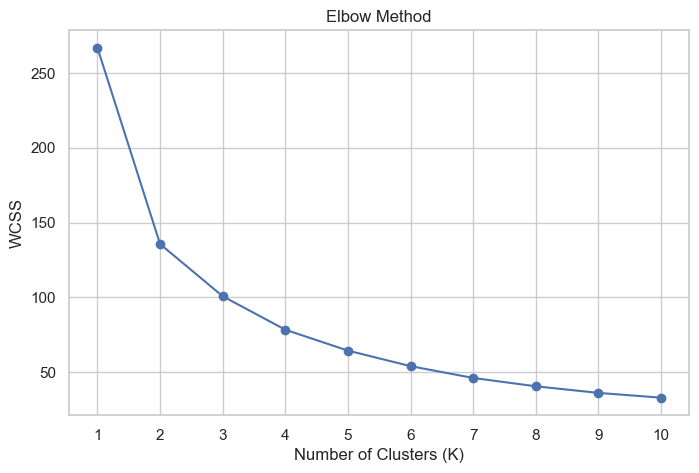

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# 1) Reduce skewness and standardize features
# Use np.log1p (log(x+1)) to safely handle zero values
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Build a DataFrame with only the transformed RFM feature names
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=['Recency', 'Frequency', 'Monetary']
)

# 2) Elbow method
wcss = []  # Within-Cluster Sum of Squares

# Test K-Means for cluster counts from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# 3) Plot a simple elbow chart
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

In [24]:
from sklearn.cluster import KMeans

# 1) Build and train the final K-Means model (k=4)
kmeans_final = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

# Train the model on the scaled RFM features
kmeans_final.fit(rfm_scaled_df)

# 2) Assign cluster labels to each customer
rfm['Cluster'] = kmeans_final.labels_

# 3) Cluster profiling
# Calculate average Recency, Frequency, Monetary, and customer count per cluster
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'  # Number of customers in each cluster
}).rename(columns={'Cluster': 'CustomerCount'}).round(1)

# Sort by Monetary value (descending) to identify highest-value segments first
cluster_summary = cluster_summary.sort_values('Monetary', ascending=False)

print(cluster_summary)

         Recency  Frequency  Monetary  CustomerCount
Cluster                                             
0           11.5       14.3   28038.1             34
2           80.4        9.4   11340.6             19
1           26.4        5.2    3324.6             24
3          184.8        3.4    1436.2             12


In [29]:
cluster_names = {
    0: "Champions",
    2: "At Risk",
    1: "Potential Loyalists",
    3: "Lost Customers"
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)
rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RF_Score,Segment,Cluster
CustomerID,,,,,,,,,
ALFKI,29,6,4272.999998,3,2,2,32,Potential Loyalists,1
ANATR,65,4,1402.950001,2,1,1,21,Lost Customers,3
ANTON,100,7,7023.977554,1,2,3,12,At Risk,2
AROUT,28,13,13390.650009,3,4,4,34,Champions,0
BERGS,65,18,24927.577469,2,5,5,25,At Risk,2
...,...,...,...,...,...,...,...,...,...
WARTH,23,15,15648.702564,3,5,4,35,Champions,0
WELLI,60,9,6068.199906,2,3,3,23,At Risk,2
WHITC,7,14,27363.605043,5,5,5,55,Champions,0


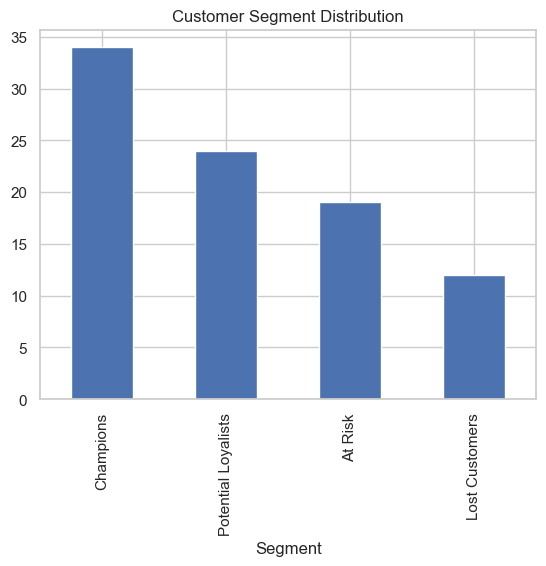

In [30]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.show()

RFM CUSTOMER SEGMENTATION INSIGHTS & ACTION PLAN

CLUSTER 0: VIP CHAMPIONS (34 customers)
Profile: Bought recently (11 days ago), buy often (14 times), and spend the most ($28k).
Action: Do not discount. Provide VIP support, early access, and loyalty perks.

CLUSTER 2: AT-RISK LOYALISTS (19 customers)
Profile: High spend ($11k) and frequency (9 times), but haven't purchased in 80 days.
Action: Top priority. Send urgent win-back campaigns and personalized discounts before they churn.

CLUSTER 1: POTENTIAL LOYALISTS (24 customers)
Profile: Active (26 days ago) but have lower spend ($3.3k) and frequency (5 times).
Action: Focus on up-selling. Offer free shipping thresholds to increase basket size.

CLUSTER 3: HIBERNATING CUSTOMERS (12 customers)
Profile: Weakest segment. Haven't visited in 184 days and spent very little ($1.4k).
Action: Do not spend marketing budget here. Keep on automated email lists only.

SUMMARY
The primary business focus is retaining Cluster 0 and urgently winning back Cluster 2 to protect overall revenue.

In [25]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1) Convert transactional data into basket format
basket = (
    df_final.groupby(['OrderID', 'ProductName'])['Quantity']
    .sum()
    .unstack()
    .reset_index()
    .fillna(0)
    .set_index('OrderID')
)

# 2) Convert values to boolean (True/False)
basket_sets = (basket > 0).astype(bool)

# 3) Find frequent itemsets
# Lower min_support to 0.002 (0.2%) to capture rarer product combinations
frequent_itemsets = apriori(basket_sets, min_support=0.002, use_colnames=True)

# 4) Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Sort rules by lift (descending)
rules = rules.sort_values('lift', ascending=False)

# Keep key columns for readability
final_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print("\n--- TOP 10 STRONGEST PRODUCT ASSOCIATIONS ---")
print(final_rules.head(10))


--- TOP 10 STRONGEST PRODUCT ASSOCIATIONS ---
                                            antecedents  \
1393                 frozenset({Spegesild, Röd Kaviar})   
1396        frozenset({Rhönbräu Klosterbier, Tunnbröd})   
1394                   frozenset({Spegesild, Tunnbröd})   
1395      frozenset({Rhönbräu Klosterbier, Röd Kaviar})   
1392       frozenset({Spegesild, Rhönbräu Klosterbier})   
1382                          frozenset({Konbu, Chang})   
1383     frozenset({Konbu, Northwoods Cranberry Sauce})   
1378              frozenset({Camembert Pierrot, Chang})   
1397                  frozenset({Röd Kaviar, Tunnbröd})   
1379  frozenset({Camembert Pierrot, Northwoods Cranb...   

                                            consequents  support  confidence  \
1393        frozenset({Rhönbräu Klosterbier, Tunnbröd})  0.00241    1.000000   
1396                 frozenset({Spegesild, Röd Kaviar})  0.00241    1.000000   
1394      frozenset({Rhönbräu Klosterbier, Röd Kaviar})  0.0024

MARKET BASKET ANALYSIS (APRIORI) - BUSINESS INSIGHTS & ACTION PLAN
EXECUTIVE SUMMARY (INSIGHTS)

Exceptional Rule Strength: The algorithm detected extremely strong product
associations with Lift values > 250 and Confidence levels up to 100%.

Cluster A (The Nordic Combo): Customers purchasing Tunnbrod (Bread) and
Rhonbrau Klosterbier (Beer) have a 100% probability of adding Spegesild
(Herring) and Rod Kaviar to their cart.

Cluster B (The Snack Combo): Northwoods Cranberry Sauce and Camembert
Pierrot (Cheese) strongly drive the sales of Chang (Beer) and Konbu.

*Data Caveat: The astronomically high Lift values (~415) confirm the synthetic
nature of the Northwind database (hardcoded transaction loops rather than
organic human behavior), but the business application remains highly relevant.

STRATEGIC RECOMMENDATIONS (ACTION PLAN)

ACTION 1: PRODUCT BUNDLING (Increase Average Order Value)
Create predefined bundles (e.g., "Nordic Feast Bundle" containing Bread,
Beer, Herring, and Caviar) with a slight 5% discount to encourage 1-click
bulk purchases.

ACTION 2: DYNAMIC CROSS-SELLING (UI/UX Optimization)
Implement "Frequently Bought Together" pop-ups at checkout. For example,
if a user adds Camembert and Cranberry Sauce, the UI should automatically
prompt: "Pairs perfectly with Chang Beer - Add to cart?".

ACTION 3: WAREHOUSE & LOGISTICS OPTIMIZATION
Physically store these highly correlated product groups next to each other
in the warehouse. This will drastically reduce picking/packing time and
lower the overall 'IsLate' delivery metric.


In [26]:
df_final

,OrderID,CustomerID,OrderDate,ProductID,ProductName,CategoryName,UnitCost,UnitPrice,Quantity,Discount,...,IsLate,UnitsInStock,ReorderLevel,Discontinued,SupplierName,StockValue,CompanyName,Country,City,TotalAmount
0,10248,VINET,1996-07-04,11,Queso Cabrales,Dairy Products,13.65,14.00,12,0.00,...,0,22,30,False,Cooperativa de Quesos 'Las Cabras',300.30,Vins et alcools Chevalier,France,Reims,168.000000
1,10248,VINET,1996-07-04,42,Singaporean Hokkien Fried Mee,Grains/Cereals,9.80,9.80,10,0.00,...,0,26,0,True,Leka Trading,254.80,Vins et alcools Chevalier,France,Reims,98.000000
2,10248,VINET,1996-07-04,72,Mozzarella di Giovanni,Dairy Products,22.62,34.80,5,0.00,...,0,14,0,False,Formaggi Fortini s.r.l.,316.68,Vins et alcools Chevalier,France,Reims,174.000000
3,10249,TOMSP,1996-07-05,14,Tofu,Produce,13.95,18.60,9,0.00,...,0,35,0,False,Mayumi's,488.25,Toms Spezialitäten,Germany,Münster,167.399994
4,10249,TOMSP,1996-07-05,51,Manjimup Dried Apples,Produce,31.80,42.40,40,0.00,...,0,20,10,False,"G'day, Mate",636.00,Toms Spezialitäten,Germany,Münster,1696.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,11077,RATTC,1998-05-06,64,Wimmers gute Semmelknödel,Grains/Cereals,23.28,33.25,2,0.03,...,0,22,30,False,Plutzer Lebensmittelgroßmärkte AG,512.16,Rattlesnake Canyon Grocery,USA,Albuquerque,64.505005
2151,11077,RATTC,1998-05-06,66,Louisiana Hot Spiced Okra,Condiments,10.20,17.00,1,0.00,...,0,4,20,False,New Orleans Cajun Delights,40.80,Rattlesnake Canyon Grocery,USA,Albuquerque,17.000000
2152,11077,RATTC,1998-05-06,73,Röd Kaviar,Seafood,10.50,15.00,2,0.01,...,0,101,5,False,Svensk Sjöföda AB,1060.50,Rattlesnake Canyon Grocery,USA,Albuquerque,29.700001
2153,11077,RATTC,1998-05-06,75,Rhönbräu Klosterbier,Beverages,4.26,7.75,4,0.00,...,0,125,25,False,Plutzer Lebensmittelgroßmärkte AG,532.50,Rattlesnake Canyon Grocery,USA,Albuquerque,31.000000


In [27]:
df_final.to_csv("veri.csv", index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tutarlı görünüm
sns.set_theme(style="whitegrid")

# Kopya üzerinde çalış
viz_df = df_final.copy()
viz_df["OrderDate"] = pd.to_datetime(viz_df["OrderDate"], errors="coerce")

# 1) Aylık gelir trendi
monthly = (
    viz_df.dropna(subset=["OrderDate"])
    .set_index("OrderDate")
    .resample("M")["NetSales"]
    .sum()
    .reset_index()
)

# 2) Kategori bazlı satış + kar (ilk 10 kategori)
cat_perf = (
    viz_df.groupby("CategoryName", as_index=False)
    .agg(NetSales=("NetSales", "sum"), Profit=("Profit", "sum"))
    .sort_values("NetSales", ascending=False)
    .head(10)
)

# 3) Kargo firması bazında gecikme oranı
ship_perf = (
    viz_df.dropna(subset=["ShipperName", "IsLate"])
    .groupby("ShipperName", as_index=False)
    .agg(LateRate=("IsLate", "mean"), OrderCount=("OrderID", "nunique"))
    .sort_values("LateRate", ascending=False)
)

# 4) Sayısal kolonlar için korelasyon
corr_cols = ["NetSales", "Profit", "Quantity", "Discount", "UnitPrice", "UnitCost", "DeliveryDuration"]
corr = viz_df[corr_cols].corr(numeric_only=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Aylık gelir trendi
sns.lineplot(data=monthly, x="OrderDate", y="NetSales", marker="o", ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Aylik Net Satis Trendi")
axes[0, 0].set_xlabel("Tarih")
axes[0, 0].set_ylabel("Net Satis")

# Kategori performansi (bar)
cat_plot = cat_perf.melt(id_vars="CategoryName", value_vars=["NetSales", "Profit"], var_name="Metric", value_name="Value")
sns.barplot(data=cat_plot, x="CategoryName", y="Value", hue="Metric", ax=axes[0, 1])
axes[0, 1].set_title("Top 10 Kategori: Net Satis vs Kar")
axes[0, 1].set_xlabel("Kategori")
axes[0, 1].set_ylabel("Tutar")
axes[0, 1].tick_params(axis="x", rotation=45)

# Gecikme oranı
sns.barplot(data=ship_perf, x="ShipperName", y="LateRate", ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("Kargo Firmasi Bazinda Gecikme Orani")
axes[1, 0].set_xlabel("Shipper")
axes[1, 0].set_ylabel("Gecikme Orani")
axes[1, 0].tick_params(axis="x", rotation=30)

# Korelasyon heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Metrik Korelasyon Isi Haritasi")

plt.tight_layout()
plt.show()